# Hoja de trabajo 2: Transformers y mecanismos de atención

## 0. Configuración del entorno

In [1]:
import os, re, math, time, json, random, platform, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModel

SEED = 42

def fijar_semilla(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for carpeta in ["figuras", "resultados"]:
    os.makedirs(carpeta, exist_ok=True)

def nombre_cpu():
    try:
        salida = subprocess.check_output(
            ["powershell", "-NoProfile", "-Command", "(Get-CimInstance Win32_Processor).Name"], text=True)
        return salida.strip()
    except Exception:
        return platform.processor()

HARDWARE = {
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU",
    "cpu": nombre_cpu(),
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
}
for k, v in HARDWARE.items():
    print(f"{k:13s}: {v}")

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "lines.linewidth": 2,
})
AZUL, NARANJA, VERDE, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"

gpu          : NVIDIA GeForce RTX 5070 Ti
cpu          : AMD Ryzen 7 7800X3D 8-Core Processor
python       : 3.12.14
torch        : 2.14.1+cu130
transformers : 5.18.0


## 1. Modelos preentrenados

Se cargan BERT base sin mayúsculas y GPT-2 pequeño tal como indica la hoja. La implementación eager calcula la atención de forma explícita, lo que permite devolver los pesos con output_attentions. Ambos modelos tienen 12 capas con 12 cabezas de dimensión 64.

In [2]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()

@torch.no_grad()
def atenciones(modelo, tok, texto):
    enc = tok(texto, return_tensors="pt")
    salida = modelo(**enc)
    A = torch.stack(salida.attentions)[:, 0]
    return A, tok.convert_ids_to_tokens(enc["input_ids"][0])

A, tokens = atenciones(bert, tok_bert, "The cat sat on the mat.")
print("BERT:", len(bert.encoder.layer), "capas | atenciones", tuple(A.shape), "| tokens", tokens)
A, tokens = atenciones(gpt2, tok_gpt2, "The cat sat on the mat.")
print("GPT-2:", len(gpt2.h), "capas | atenciones", tuple(A.shape), "| tokens", tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

BERT: 12 capas | atenciones (12, 12, 9, 9) | tokens ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
GPT-2: 12 capas | atenciones (12, 12, 7, 7) | tokens ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', '.']


## 2. Investigación: de las RNN a la atención

### Cuello de botella de seq2seq

En un encoder-decoder con RNN el encoder resume toda la oración en un único vector de tamaño fijo, su último estado oculto, y el decoder genera la salida solo a partir de él. Ese vector es el cuello de botella: la cantidad de información que puede guardar no crece con la oración, así que en oraciones largas los primeros tokens se diluyen y la calidad de la traducción cae. La atención de Bahdanau conserva todos los estados del encoder y, en cada paso del decoder, calcula un peso para cada estado según su relevancia y usa su promedio ponderado como contexto. Así el decoder consulta directamente la parte de la entrada que necesita.

### Atención aditiva y multiplicativa

Bahdanau calcula la puntuación con una pequeña red: v · tanh(W s + U h). Luong usa un producto punto, s · h, o una forma bilineal s · W h. La multiplicativa es más eficiente en hardware moderno porque todas las puntuaciones de una secuencia salen de una sola multiplicación de matrices, la operación que GPUs y TPUs ejecutan con mayor rendimiento, mientras que la aditiva necesita una capa con tanh por cada par de posiciones y más memoria intermedia.

### Consulta, llave y valor

La atención funciona como un diccionario suave. En un diccionario normal la consulta coincide exactamente con una llave y se devuelve su valor. En la atención la consulta se compara con todas las llaves, la softmax convierte las similitudes en pesos que suman 1 y se devuelve el promedio ponderado de todos los valores. En self-attention Q, K y V salen de la misma secuencia multiplicada por tres matrices aprendidas. En cross-attention Q sale del decoder y K y V salen de la salida del encoder.

### Limitaciones de las RNN que elimina el Transformer

Una RNN procesa un token a la vez, así que no se puede paralelizar a lo largo de la secuencia. La información entre dos tokens separados por n posiciones recorre n pasos, lo que dificulta las dependencias de largo alcance, y el gradiente se multiplica por la misma matriz en cada paso, lo que lo desvanece o lo hace explotar. El Transformer conecta cualquier par de tokens en un solo paso, procesa todas las posiciones en paralelo y su gradiente pasa por conexiones residuales en lugar de una cadena temporal.

## 3. Investigación: la arquitectura Transformer

### Scaled dot-product attention

Attention(Q, K, V) = softmax(QKᵀ / √d_k) V. Si los componentes de q y k son independientes con media 0 y varianza 1, cada producto q_i k_i tiene media 0 y varianza 1, y la suma de d_k términos independientes tiene varianza d_k. Sin escalar, las puntuaciones crecen con la dimensión, la softmax se satura dando casi todo el peso a una sola llave y su jacobiano tiende a cero, así que los gradientes desaparecen. Dividir entre √d_k devuelve la varianza a 1. La sección 6.3 lo verifica.

### Multi-head attention

Con h cabezas de dimensión d_model/h, cada cabeza proyecta a un subespacio distinto y puede atender a un tipo de relación diferente, por ejemplo sintaxis en una y posición en otra, mientras que una sola cabeza promedia todo en una única distribución. El número de parámetros no cambia: las proyecciones siguen siendo de d_model por d_model y solo se reparten entre las cabezas. El costo de cómputo también es prácticamente el mismo.

### Codificación posicional

La self-attention es equivariante a permutaciones: si se reordenan los tokens de entrada, las salidas se reordenan igual, porque cada token se compara con todos sin importar dónde está. Por eso necesita información de posición. La codificación sinusoidal suma a cada embedding senos y cosenos de frecuencias geométricas, PE(pos, 2i) = sin(pos / 10000^(2i/d)), lo que permite expresar desplazamientos relativos como transformaciones lineales y extrapolar a longitudes no vistas. Los embeddings posicionales aprendidos, usados por BERT y GPT-2, son una tabla entrenada por posición: se adaptan a los datos pero no sirven más allá de la longitud máxima. RoPE rota q y k según su posición, de modo que el producto punto depende solo de la distancia relativa, y es el esquema de la mayoría de los modelos actuales.

### Bloque completo

Cada subcapa, atención o red feed-forward, se envuelve en una conexión residual y una LayerNorm. La residual deja pasar la señal y el gradiente sin cambios por la profundidad, la LayerNorm estabiliza la escala de las activaciones, y la red feed-forward aplica a cada posición por separado dos capas lineales con una activación, expandiendo de d_model a 4 d_model y volviendo. En Post-LN, el diseño original, la normalización va después de sumar la residual, lo que exige warmup y es inestable en redes profundas. En Pre-LN la normalización va antes de la subcapa y la residual queda limpia, así que el gradiente fluye mejor y se entrena sin warmup largo, aunque suele necesitar una normalización final.

### Complejidad

La self-attention cuesta O(n² d) en tiempo y O(n²) en memoria por cabeza, porque forma la matriz de puntuaciones de n por n. FlashAttention calcula la atención exacta por bloques sin guardar la matriz completa, lo que lleva la memoria a O(n) pero mantiene el tiempo cuadrático y requiere kernels específicos de GPU. La atención por ventanas, como Longformer, limita cada token a w vecinos y da O(n w), pero sacrifica la conexión directa entre tokens lejanos. La atención lineal reemplaza la softmax por un kernel que permite asociar K y V primero y da O(n), a cambio de una aproximación que suele perder precisión.

## 4. Investigación: atención en PyTorch y Hugging Face

F.scaled_dot_product_attention calcula softmax(QKᵀ/√d)V y elige automáticamente un backend eficiente como FlashAttention. attn_mask es una máscara booleana, donde True permite atender, o un tensor que se suma a las puntuaciones. dropout_p aplica dropout a los pesos, is_causal aplica la máscara triangular sin construirla y scale reemplaza el 1/√d por defecto.

In [3]:
q = torch.randn(1, 2, 4, 8)
salida = F.scaled_dot_product_attention(q, q, q, is_causal=True)
print("F.scaled_dot_product_attention:", tuple(salida.shape))
print(nn.Transformer.generate_square_subsequent_mask(4))

F.scaled_dot_product_attention: (1, 2, 4, 8)
tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])


nn.MultiheadAttention implementa la atención multi-cabeza con sus proyecciones. embed_dim es d_model y num_heads el número de cabezas, que debe dividir a embed_dim. batch_first indica si la entrada es lote por secuencia por dimensión, y kdim y vdim permiten que llaves y valores tengan otra dimensión, como en cross-attention. En su forward, key_padding_mask marca con True las posiciones de relleno que no deben recibir atención, attn_mask bloquea pares de posiciones, como en la máscara causal, need_weights decide si se devuelven los pesos y average_attn_weights si se promedian entre cabezas o se devuelven por cabeza.

nn.TransformerEncoderLayer es un bloque completo de encoder. d_model y nhead definen la atención, dim_feedforward el tamaño oculto de la red feed-forward, dropout la regularización y norm_first elige Pre-LN si es True o Post-LN si es False. nn.Transformer.generate_square_subsequent_mask(n) crea la máscara causal de n por n con −inf sobre la diagonal y 0 en el resto, que se suma a las puntuaciones para que cada posición solo vea las anteriores.

En Hugging Face, output_attentions=True hace que el modelo devuelva una tupla con un tensor por capa de forma lote por cabezas por n por n, donde la fila i son los pesos con que el token i atiende a cada token. Requiere la implementación eager, porque los kernels fusionados no materializan la matriz de pesos.

In [4]:
mha = nn.MultiheadAttention(embed_dim=16, num_heads=4, batch_first=True)
x = torch.randn(2, 5, 16)
relleno = torch.tensor([[False] * 5, [False, False, False, True, True]])
salida, pesos = mha(x, x, x, key_padding_mask=relleno, need_weights=True, average_attn_weights=False)
print("salida", tuple(salida.shape), "| pesos por cabeza", tuple(pesos.shape))
print("peso total sobre relleno en el segundo ejemplo:", pesos[1, :, :, 3:].sum().item())

capa_post = nn.TransformerEncoderLayer(d_model=16, nhead=4, dim_feedforward=64, dropout=0.1, norm_first=False, batch_first=True)
capa_pre = nn.TransformerEncoderLayer(d_model=16, nhead=4, dim_feedforward=64, dropout=0.1, norm_first=True, batch_first=True)
print("Post-LN y Pre-LN tienen", sum(p.numel() for p in capa_post.parameters()), "y",
      sum(p.numel() for p in capa_pre.parameters()), "parámetros")

salida (2, 5, 16) | pesos por cabeza (2, 4, 5, 5)
peso total sobre relleno en el segundo ejemplo: 0.0
Post-LN y Pre-LN tienen 3280 y 3280 parámetros


## 5. Visualización de atención en modelos preentrenados

### 5.1 Patrones por cabeza

Para cada una de las 144 cabezas de cada modelo se miden seis patrones, promediados sobre un conjunto de oraciones: atención al token anterior, al siguiente, al primer token, que en BERT es [CLS], al último, que en BERT es [SEP], a la puntuación y a sí mismo. Luego se elige la cabeza más fuerte en cuatro patrones, con la condición de que estén en capas distintas, y se grafica en una oración de ejemplo.

In [5]:
FRASES = [
    "The cat sat on the mat, and the cat looked at the dog.",
    "The animal didn't cross the street because it was too tired.",
    "The animal didn't cross the street because it was too wide.",
    "She gave the book to her brother because he wanted to read it.",
    "Deep learning models learn representations from large amounts of data.",
    "When the rain stopped, the children ran outside to play.",
    "The company reported higher profits, but its shares fell sharply.",
    "Paris is the capital of France, and Rome is the capital of Italy.",
]
EJEMPLO = FRASES[0]
PUNTUACION = {",", ".", "'", "!", "?", ":"}

def patrones(A, tokens):
    n = A.shape[-1]
    i = torch.arange(1, n)
    punt = [j for j, t in enumerate(tokens) if t.replace("Ġ", "") in PUNTUACION]
    return {
        "anterior": A[..., i, i - 1].mean(-1),
        "siguiente": A[..., i[:-1] - 1, i[:-1]].mean(-1),
        "primer token": A[..., 1:, 0].mean(-1),
        "último token": A[..., :-1, n - 1].mean(-1),
        "puntuación": A[..., :, punt].sum(-1).mean(-1),
        "sí mismo": torch.diagonal(A, dim1=-2, dim2=-1).mean(-1),
    }

def patrones_promedio(modelo, tok):
    acumulado = None
    for frase in FRASES:
        p = patrones(*atenciones(modelo, tok, frase))
        acumulado = p if acumulado is None else {k: acumulado[k] + p[k] for k in p}
    return {k: v / len(FRASES) for k, v in acumulado.items()}

def elegir_cabezas(pat, orden):
    elegidas, capas = [], set()
    for nombre in orden:
        puntaje = pat[nombre].clone()
        puntaje[list(capas)] = -1
        capa, cabeza = divmod(int(puntaje.argmax()), puntaje.shape[1])
        elegidas.append((nombre, capa, cabeza, float(pat[nombre][capa, cabeza])))
        capas.add(capa)
    return elegidas

PAT_BERT = patrones_promedio(bert, tok_bert)
PAT_GPT2 = patrones_promedio(gpt2, tok_gpt2)
CAB_BERT = elegir_cabezas(PAT_BERT, ["anterior", "siguiente", "último token", "sí mismo"])
CAB_GPT2 = elegir_cabezas(PAT_GPT2, ["anterior", "primer token", "puntuación", "sí mismo"])
for nombre, cab in [("BERT", CAB_BERT), ("GPT-2", CAB_GPT2)]:
    for patron, capa, cabeza, valor in cab:
        print(f"{nombre:6s} {patron:13s} capa {capa + 1:2d} cabeza {cabeza + 1:2d} | peso medio {valor:.3f}")

BERT   anterior      capa  4 cabeza  6 | peso medio 0.643
BERT   siguiente     capa  3 cabeza 10 | peso medio 0.925
BERT   último token  capa  6 cabeza  2 | peso medio 0.867
BERT   sí mismo      capa 12 cabeza  9 | peso medio 0.401
GPT-2  anterior      capa  5 cabeza 12 | peso medio 0.999
GPT-2  primer token  capa  8 cabeza  3 | peso medio 0.989
GPT-2  puntuación    capa  3 cabeza  6 | peso medio 0.121
GPT-2  sí mismo      capa  1 cabeza  2 | peso medio 0.934


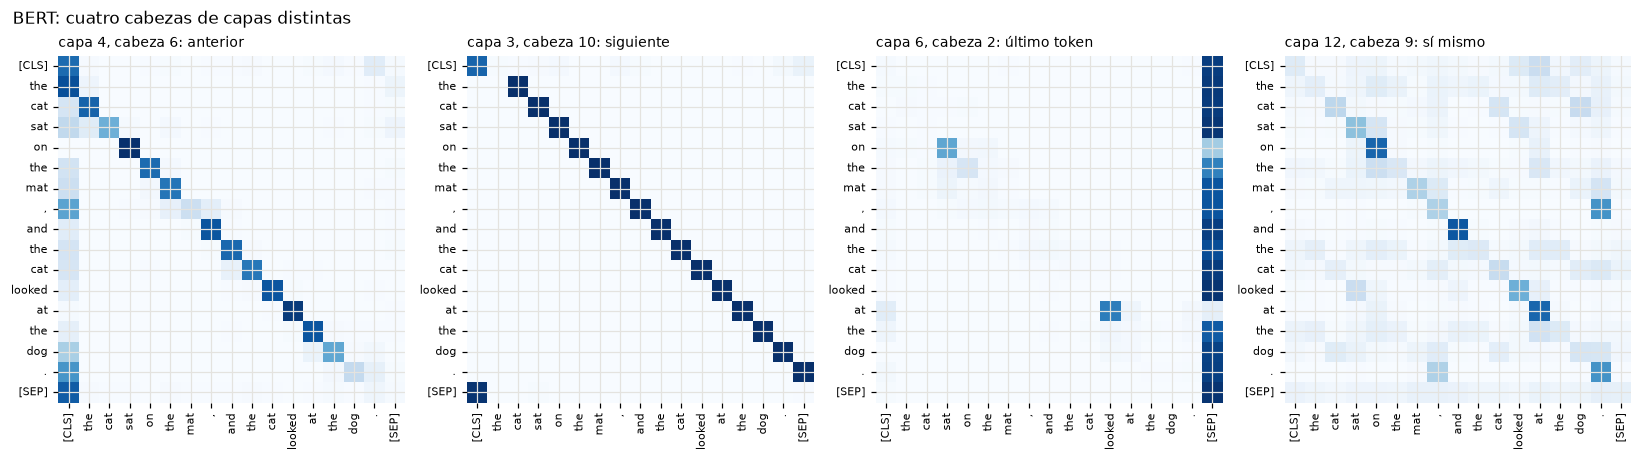

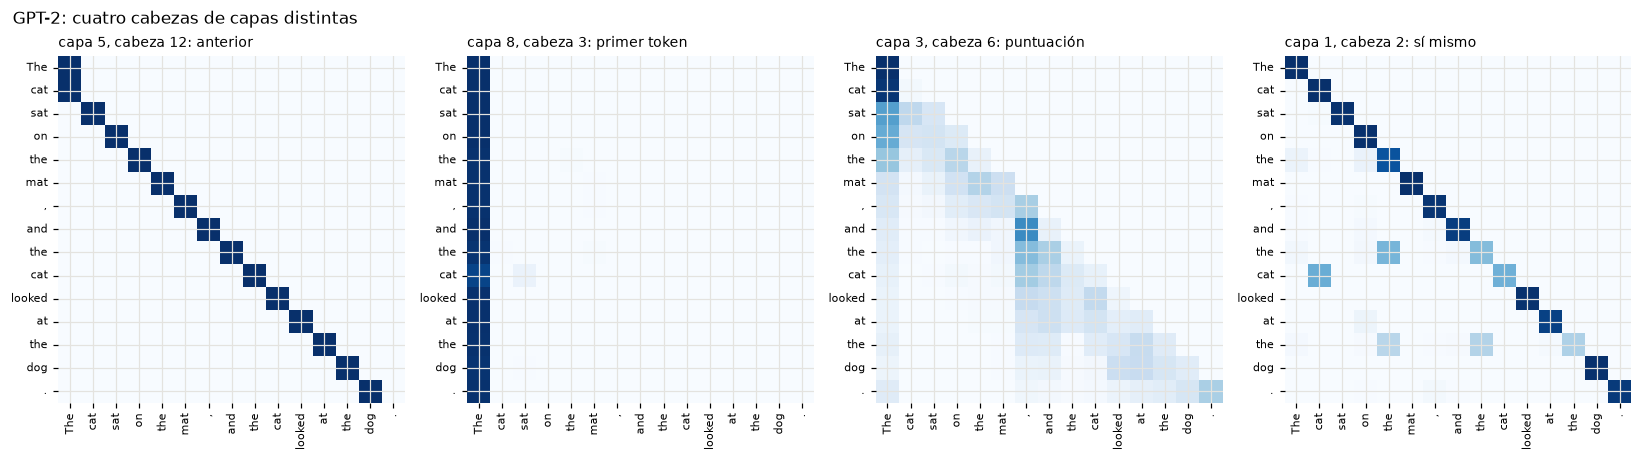

In [6]:
def graficar_cabezas(modelo, tok, cabezas, titulo, archivo):
    A, tokens = atenciones(modelo, tok, EJEMPLO)
    tokens = [t.replace("Ġ", "") for t in tokens]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for ax, (patron, capa, cabeza, _) in zip(axes, cabezas):
        sns.heatmap(A[capa, cabeza].numpy(), ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False, square=True,
                    xticklabels=tokens, yticklabels=tokens)
        ax.set_title(f"capa {capa + 1}, cabeza {cabeza + 1}: {patron}", fontsize=9, loc="left")
        ax.tick_params(labelsize=7)
    fig.suptitle(titulo, x=0.01, ha="left")
    plt.tight_layout()
    plt.savefig(f"figuras/{archivo}")
    plt.show()

graficar_cabezas(bert, tok_bert, CAB_BERT, "BERT: cuatro cabezas de capas distintas", "cabezas_bert.png")
graficar_cabezas(gpt2, tok_gpt2, CAB_GPT2, "GPT-2: cuatro cabezas de capas distintas", "cabezas_gpt2.png")

In [7]:
def resumen_patrones(pat, umbral=0.5):
    return pd.DataFrame({k: {"máximo": round(float(v.max()), 3), "promedio": round(float(v.mean()), 3),
                             f"cabezas sobre {umbral}": int((v > umbral).sum())} for k, v in pat.items()}).T

print("BERT")
display(resumen_patrones(PAT_BERT))
print("GPT-2")
display(resumen_patrones(PAT_GPT2))

BERT


,máximo,promedio,cabezas sobre 0.5
anterior,0.643,0.071,2.0
siguiente,0.925,0.074,3.0
primer token,0.913,0.122,2.0
último token,0.867,0.334,44.0
puntuación,0.743,0.146,16.0
sí mismo,0.412,0.098,0.0


GPT-2


,máximo,promedio,cabezas sobre 0.5
anterior,0.999,0.167,2.0
siguiente,0.000,0.000,0.0
primer token,0.989,0.629,104.0
último token,0.000,0.000,0.0
puntuación,0.121,0.026,0.0
sí mismo,0.934,0.160,5.0


Los patrones posicionales aparecen en cabezas casi puras. En BERT la capa 4, cabeza 6 atiende al token anterior con peso medio 0.64 y la capa 3, cabeza 10 al siguiente con 0.93, y la capa 6, cabeza 2 manda 0.87 de su atención a [SEP].

### 5.2 Correferencia de it


In [8]:
FRASE_TIRED = "The animal didn't cross the street because it was too tired."
FRASE_WIDE = "The animal didn't cross the street because it was too wide."

def peso_it(modelo, tok, frase):
    A, tokens = atenciones(modelo, tok, frase)
    tokens = [t.replace("Ġ", "") for t in tokens]
    # posiciones de interés
    i, a, s = tokens.index("it"), tokens.index("animal"), tokens.index("street")
    return A[:, :, i, a], A[:, :, i, s], A[:, :, i], tokens

an_t, st_t, fila_t, tok_t = peso_it(bert, tok_bert, FRASE_TIRED)
an_w, st_w, fila_w, tok_w = peso_it(bert, tok_bert, FRASE_WIDE)
margen = torch.minimum(an_t - st_t, st_w - an_w)
print(f"Cabezas de BERT que cumplen ambos casos: {int((margen > 0).sum())} de 144")

ranking = pd.DataFrame([{"capa": c + 1, "cabeza": h + 1, "tired: animal": round(float(an_t[c, h]), 3),
                         "tired: street": round(float(st_t[c, h]), 3), "wide: animal": round(float(an_w[c, h]), 3),
                         "wide: street": round(float(st_w[c, h]), 3), "margen": round(float(margen[c, h]), 3)}
                        for c in range(12) for h in range(12)]).sort_values("margen", ascending=False)
display(ranking.head(8))
MEJOR_IT = (int(ranking.iloc[0]["capa"]) - 1, int(ranking.iloc[0]["cabeza"]) - 1)

g_an_t, g_st_t, g_fila_t, _ = peso_it(gpt2, tok_gpt2, FRASE_TIRED)
g_an_w, g_st_w, g_fila_w, _ = peso_it(gpt2, tok_gpt2, FRASE_WIDE)
print("GPT-2: diferencia máxima entre las filas de it en ambas oraciones:", float((g_fila_t - g_fila_w).abs().max()))

Cabezas de BERT que cumplen ambos casos: 22 de 144


,capa,cabeza,tired: animal,tired: street,wide: animal,wide: street,margen
82,7,11,0.284,0.067,0.012,0.590,0.217
100,9,5,0.242,0.014,0.046,0.209,0.163
103,9,8,0.205,0.050,0.061,0.194,0.133
58,5,11,0.333,0.095,0.167,0.288,0.121
76,7,5,0.239,0.134,0.081,0.251,0.105
99,9,4,0.082,0.026,0.013,0.159,0.057
97,9,2,0.115,0.004,0.015,0.056,0.041
140,12,9,0.045,0.007,0.017,0.076,0.037


GPT-2: diferencia máxima entre las filas de it en ambas oraciones: 0.0


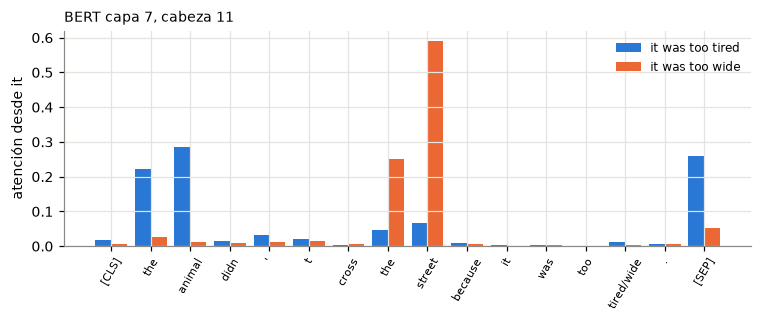

In [9]:
c, h = MEJOR_IT
fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(tok_t))
ax.bar(x - 0.2, fila_t[c, h].numpy(), width=0.4, color=AZUL, label="it was too tired")
ax.bar(x + 0.2, fila_w[c, h].numpy(), width=0.4, color=NARANJA, label="it was too wide")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}/{b}" if a != b else a for a, b in zip(tok_t, tok_w)], rotation=60, fontsize=7)
ax.set_ylabel("atención desde it")
ax.set_title(f"BERT capa {c + 1}, cabeza {h + 1}", loc="left", fontsize=9)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("figuras/it_bert.png")
plt.show()

22 de las 144 cabezas de BERT cumplen ambos casos, sobre todo en las capas 5 a 9. La más clara es la capa 7, cabeza 11: con tired, it da 0.28 a animal y 0.07 a street, y con wide da 0.59 a street y solo 0.01 a animal. Como BERT es bidireccional, it ve el adjetivo que aparece después y puede cambiar su referente. En GPT-2 la fila de it es exactamente igual en las dos oraciones, con diferencia máxima de 0, porque la máscara causal impide que it vea tired o wide, que vienen después.

### 5.3 GPT-2: máscara causal y sumideros de atención

Se verifica que todas las matrices de GPT-2 son triangulares inferiores y se mide qué proporción de la atención recibe el primer token en cada capa, sin contar la primera fila, que solo puede atenderse a sí misma. Para comprobar que el efecto no depende del contenido del primer token, se repite la medición anteponiendo un token neutro, el salto de línea, a cada oración.

In [10]:
def primer_token_por_capa(modelo, tok, prefijo=""):
    valores, max_triu = [], 0.0
    for frase in FRASES:
        A, _ = atenciones(modelo, tok, prefijo + frase)
        max_triu = max(max_triu, float(torch.triu(A, diagonal=1).abs().max()))
        valores.append(A[:, :, 1:, 0].mean(dim=(1, 2)))
    return torch.stack(valores).mean(0).numpy(), max_triu

PRIMER_GPT2, max_triu = primer_token_por_capa(gpt2, tok_gpt2)
PRIMER_GPT2_NL, _ = primer_token_por_capa(gpt2, tok_gpt2, "\n")
print(f"Máximo sobre la diagonal en todas las capas y oraciones de GPT-2: {max_triu:.1e}")

cls_bert, sep_bert = [], []
for frase in FRASES:
    A, _ = atenciones(bert, tok_bert, frase)
    cls_bert.append(A[:, :, :, 0].mean(dim=(1, 2)))
    sep_bert.append(A[:, :, :, -1].mean(dim=(1, 2)))
CLS_BERT = torch.stack(cls_bert).mean(0).numpy()
SEP_BERT = torch.stack(sep_bert).mean(0).numpy()
tabla_sumidero = pd.DataFrame({"GPT-2 primer token": PRIMER_GPT2, "GPT-2 primer token con salto de línea": PRIMER_GPT2_NL,
                               "BERT [CLS]": CLS_BERT, "BERT [SEP]": SEP_BERT}, index=range(1, 13)).round(3)
display(tabla_sumidero)

Máximo sobre la diagonal en todas las capas y oraciones de GPT-2: 0.0e+00


,GPT-2 primer token,GPT-2 primer token con salto de línea,BERT [CLS],BERT [SEP]
1,0.249,0.220,0.143,0.073
2,0.416,0.384,0.416,0.087
3,0.413,0.367,0.364,0.100
4,0.556,0.545,0.261,0.220
5,0.582,0.573,0.051,0.527
6,0.732,0.734,0.037,0.593
7,0.717,0.719,0.036,0.572
8,0.804,0.808,0.026,0.560
9,0.740,0.729,0.032,0.572
10,0.817,0.821,0.062,0.511


Todas las matrices de GPT-2 tienen peso 0 sobre la diagonal, así que son triangulares inferiores. El primer token recibe el 25 % de la atención en la capa 1 y entre 69 y 83 % desde la capa 6. Es el fenómeno de attention sinks de Xiao et al.: la softmax obliga a que los pesos sumen 1, así que una cabeza que no encuentra nada útil que leer descarga su peso en un token que todos pueden ver, el primero en un modelo causal. El contenido del primer token no importa, porque al anteponer un salto de línea las proporciones casi no cambian. Por eso StreamingLLM conserva los primeros tokens al usar una ventana deslizante. BERT tiene un comportamiento análogo con [SEP], que recibe más del 50 % de la atención entre las capas 5 y 10, mientras que [CLS] solo es importante en las capas 2 y 3.

### 5.4 Entropía de la atención por capa

La entropía de cada fila mide qué tan repartida está la atención: 0 si todo va a un token y log k si se reparte igual entre k tokens. Como en GPT-2 la fila i solo puede atender a i tokens, además de la entropía en nats se calcula la entropía normalizada, dividida entre log k, que compara ambos modelos en la misma escala. Se excluye la primera fila de GPT-2.

,BERT nats,GPT-2 nats,BERT normalizada,GPT-2 normalizada
1,2.079,1.307,0.762,0.681
2,1.640,1.414,0.601,0.714
3,1.435,1.286,0.526,0.657
4,1.633,1.024,0.599,0.525
5,1.385,0.873,0.507,0.443
6,1.172,0.798,0.429,0.407
7,1.201,0.883,0.440,0.452
8,1.156,0.652,0.423,0.332
9,1.367,0.836,0.500,0.430
10,1.530,0.604,0.560,0.311


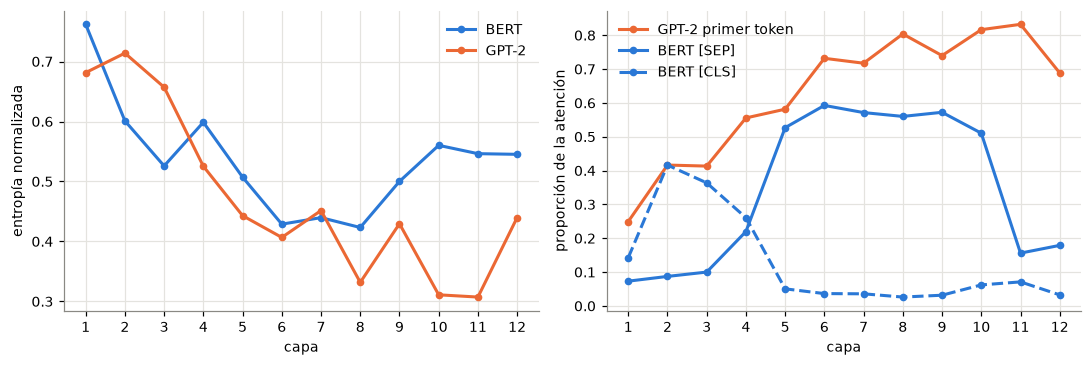

In [11]:
def entropia_por_capa(modelo, tok, causal):
    crudas, normalizadas = [], []
    for frase in FRASES:
        A, _ = atenciones(modelo, tok, frase)
        n = A.shape[-1]
        H = -(A * torch.log(A.clamp_min(1e-12))).sum(-1)
        k = torch.arange(1, n + 1) if causal else torch.full((n,), n)
        filas = slice(1, None) if causal else slice(None)
        crudas.append(H[:, :, filas].mean(dim=(1, 2)))
        normalizadas.append((H[:, :, filas] / torch.log(k[filas].float())).mean(dim=(1, 2)))
    return torch.stack(crudas).mean(0).numpy(), torch.stack(normalizadas).mean(0).numpy()

H_BERT, HN_BERT = entropia_por_capa(bert, tok_bert, causal=False)
H_GPT2, HN_GPT2 = entropia_por_capa(gpt2, tok_gpt2, causal=True)
tabla_entropia = pd.DataFrame({"BERT nats": H_BERT, "GPT-2 nats": H_GPT2, "BERT normalizada": HN_BERT,
                               "GPT-2 normalizada": HN_GPT2}, index=range(1, 13)).round(3)
display(tabla_entropia)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
capas = np.arange(1, 13)
axes[0].plot(capas, HN_BERT, color=AZUL, marker="o", ms=4, label="BERT")
axes[0].plot(capas, HN_GPT2, color=NARANJA, marker="o", ms=4, label="GPT-2")
axes[0].set_xlabel("capa")
axes[0].set_ylabel("entropía normalizada")
axes[0].legend(frameon=False)
axes[1].plot(capas, PRIMER_GPT2, color=NARANJA, marker="o", ms=4, label="GPT-2 primer token")
axes[1].plot(capas, SEP_BERT, color=AZUL, marker="o", ms=4, label="BERT [SEP]")
axes[1].plot(capas, CLS_BERT, color=AZUL, ls="--", marker="o", ms=4, label="BERT [CLS]")
axes[1].set_xlabel("capa")
axes[1].set_ylabel("proporción de la atención")
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xticks(capas)
plt.tight_layout()
plt.savefig("figuras/entropia_sumidero.png")
plt.show()

Las capas profundas atienden de forma más concentrada. En BERT la entropía normalizada baja de 0.76 en la capa 1 a 0.42 en la capa 8 y vuelve a subir a 0.55 en las últimas capas. En GPT-2 baja de 0.71 en la capa 2 a 0.31 en las capas 10 y 11. En nats, BERT pasa de 2.08 a 1.16 y GPT-2 de 1.41 a 0.60. Las primeras capas mezclan información de muchos tokens, y las profundas concentran el peso en pocos, en buena parte en los sumideros, lo que coincide con las curvas de la derecha. GPT-2 es más concentrado que BERT en las capas finales porque su sumidero es más fuerte.

## 6. Implementación, verificaciones y costo

### 6.1 Ejercicio a mano

Se calcula a mano la atención de tres tokens con d_k = 2. Cada paso se imprime para seguir el procedimiento: puntuaciones QKᵀ, escalamiento entre √2, softmax por fila y promedio ponderado de V.

In [12]:
Q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
K = torch.tensor([[1., 0.], [1., 1.], [0., 1.]])
V = torch.tensor([[1., 0.], [0., 2.], [3., 1.]])

puntuaciones = Q @ K.T
escaladas = puntuaciones / math.sqrt(2)
pesos = torch.softmax(escaladas, dim=-1)
salida = pesos @ V
torch.set_printoptions(precision=4, sci_mode=False)
print("QK^T =\n", puntuaciones)
print("QK^T / sqrt(2) =\n", escaladas)
print("exp de la fila 1:", torch.exp(escaladas[0]), "| suma:", torch.exp(escaladas[0]).sum())
print("softmax =\n", pesos)
print("salida = pesos V =\n", salida)
print("F.scaled_dot_product_attention =\n", F.scaled_dot_product_attention(Q[None], K[None], V[None])[0])

QK^T =
 tensor([[1., 1., 0.],
        [0., 1., 1.],
        [1., 2., 1.]])
QK^T / sqrt(2) =
 tensor([[0.7071, 0.7071, 0.0000],
        [0.0000, 0.7071, 0.7071],
        [0.7071, 1.4142, 0.7071]])
exp de la fila 1: tensor([2.0281, 2.0281, 1.0000]) | suma: tensor(5.0562)
softmax =
 tensor([[0.4011, 0.4011, 0.1978],
        [0.1978, 0.4011, 0.4011],
        [0.2483, 0.5035, 0.2483]])
salida = pesos V =
 tensor([[0.9944, 1.0000],
        [1.4011, 1.2033],
        [0.9930, 1.2552]])
F.scaled_dot_product_attention =
 tensor([[0.9944, 1.0000],
        [1.4011, 1.2033],
        [0.9930, 1.2552]])


### 6.2 Verificaciones

Se implementa la atención de producto punto escalado y una capa multi-cabeza propias, y se comparan con PyTorch y con BERT. También se verifican tres propiedades: las filas suman 1, la máscara causal produce matrices triangulares inferiores y la self-attention sin posiciones es equivariante a permutaciones.

In [13]:
def atencion(Q, K, V, mascara=None):
    puntuaciones = Q @ K.transpose(-2, -1) / math.sqrt(Q.shape[-1])
    if mascara is not None:
        # bloquear posiciones
        puntuaciones = puntuaciones.masked_fill(~mascara, float("-inf"))
    pesos = torch.softmax(puntuaciones, dim=-1)
    return pesos @ V, pesos

class AtencionMultiCabeza(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        self.h, self.d = h, d_model // h
        self.W_q, self.W_k, self.W_v, self.W_o = [nn.Linear(d_model, d_model) for _ in range(4)]

    def forward(self, x, mascara=None):
        B, n, _ = x.shape
        separar = lambda t: t.view(B, n, self.h, self.d).transpose(1, 2)
        salida, pesos = atencion(separar(self.W_q(x)), separar(self.W_k(x)), separar(self.W_v(x)), mascara)
        return self.W_o(salida.transpose(1, 2).reshape(B, n, -1)), pesos

fijar_semilla()
Q, K, V = torch.randn(3, 2, 4, 10, 16).unbind(0)
causal = torch.tril(torch.ones(10, 10, dtype=torch.bool))
relleno = torch.ones(2, 1, 1, 10, dtype=torch.bool)
relleno[1, ..., 7:] = False
VERIF = {}
for nombre, mascara in [("sin máscara", None), ("causal", causal), ("relleno", relleno)]:
    propio, pesos = atencion(Q, K, V, mascara)
    referencia = F.scaled_dot_product_attention(Q, K, V, attn_mask=mascara)
    VERIF[f"atención propia contra PyTorch, {nombre}"] = float((propio - referencia).abs().max())
VERIF["filas que suman 1, error máximo"] = float((pesos.sum(-1) - 1).abs().max())
_, pesos_causal = atencion(Q, K, V, causal)
VERIF["peso sobre la diagonal con máscara causal"] = float(torch.triu(pesos_causal, 1).abs().max())

mha_torch = nn.MultiheadAttention(64, 8, batch_first=True)
mha_propia = AtencionMultiCabeza(64, 8)
with torch.no_grad():
    for i, lineal in enumerate([mha_propia.W_q, mha_propia.W_k, mha_propia.W_v]):
        lineal.weight.copy_(mha_torch.in_proj_weight[64 * i:64 * (i + 1)])
        lineal.bias.copy_(mha_torch.in_proj_bias[64 * i:64 * (i + 1)])
    mha_propia.W_o.weight.copy_(mha_torch.out_proj.weight)
    mha_propia.W_o.bias.copy_(mha_torch.out_proj.bias)
    x = torch.randn(2, 12, 64)
    sal_p, pes_p = mha_propia(x)
    sal_t, pes_t = mha_torch(x, x, x, average_attn_weights=False)
    VERIF["multi-cabeza propia contra nn.MultiheadAttention, salida"] = float((sal_p - sal_t).abs().max())
    VERIF["multi-cabeza propia contra nn.MultiheadAttention, pesos"] = float((pes_p - pes_t).abs().max())
    perm = torch.randperm(12)
    sal_perm, _ = mha_propia(x[:, perm])
    VERIF["equivarianza a permutaciones sin posiciones"] = float((sal_perm - sal_p[:, perm]).abs().max())

params = lambda h: sum(p.numel() for p in nn.MultiheadAttention(768, h).parameters())
VERIF["parámetros con 1 cabeza de 768"] = params(1)
VERIF["parámetros con 12 cabezas de 64"] = params(12)

La última verificación reproduce los pesos de atención de la primera capa de BERT a partir de sus matrices de consulta y llave aplicadas a la salida de los embeddings. Si coinciden con los que devuelve output_attentions, la fórmula implementada es exactamente la que usa el modelo.

In [14]:
with torch.no_grad():
    enc = tok_bert(EJEMPLO, return_tensors="pt")
    salida = bert(**enc, output_hidden_states=True)
    capa = bert.encoder.layer[0].attention.self
    h0 = salida.hidden_states[0]
    separar = lambda t: t.view(1, -1, 12, 64).transpose(1, 2)
    _, pesos_propios = atencion(separar(capa.query(h0)), separar(capa.key(h0)), separar(capa.value(h0)))
    VERIF["pesos propios contra BERT capa 1"] = float((pesos_propios[0] - salida.attentions[0][0]).abs().max())

tabla_verif = pd.DataFrame({"resultado": VERIF})
display(tabla_verif)

,resultado
"atención propia contra PyTorch, sin máscara",3.576279e-07
"atención propia contra PyTorch, causal",4.768372e-07
"atención propia contra PyTorch, relleno",3.576279e-07
"filas que suman 1, error máximo",1.788139e-07
peso sobre la diagonal con máscara causal,0.000000e+00
"multi-cabeza propia contra nn.MultiheadAttention, salida",1.192093e-07
"multi-cabeza propia contra nn.MultiheadAttention, pesos",5.960464e-08
equivarianza a permutaciones sin posiciones,1.192093e-07
parámetros con 1 cabeza de 768,2.362368e+06
parámetros con 12 cabezas de 64,2.362368e+06


Todas las verificaciones se cumplen. La atención propia coincide con F.scaled_dot_product_attention sin máscara, con máscara causal y con máscara de relleno, con errores de 10⁻⁷, del orden de la precisión de float32. La multi-cabeza propia reproduce a nn.MultiheadAttention en salida y pesos, y aplicada a los embeddings de BERT reproduce exactamente los pesos de su primera capa, lo que confirma que el modelo usa la misma fórmula. Las filas suman 1, la máscara causal deja ceros sobre la diagonal y permutar la entrada sin codificación posicional solo permuta la salida, lo que demuestra que la self-attention no conoce el orden por sí sola. Una cabeza de 768 o 12 de 64 tienen los mismos 2,362,368 parámetros.

### 6.3 Escalamiento entre √d_k

Se muestrean vectores q y k con componentes normales independientes de media 0 y varianza 1 para varias dimensiones, y se mide la varianza de q · k con y sin escalamiento. Después se aplica la softmax a 64 puntuaciones de ese tipo y se miden el peso máximo, que indica saturación, y la norma del jacobiano de la softmax, que controla el tamaño de los gradientes.

,d_k,versión,varianza de q·k,peso máximo,norma del jacobiano
0,4,sin escalar,4.1488,0.2866,0.2650
1,4,escalado,1.0372,0.1102,0.1845
2,16,sin escalar,15.6329,0.5637,0.2991
3,16,escalado,0.9771,0.1069,0.1837
4,64,sin escalar,62.8130,0.7856,0.2173
5,64,escalado,0.9815,0.1041,0.1819
6,256,sin escalar,257.8150,0.8956,0.1287
7,256,escalado,1.0071,0.1064,0.1836
8,1024,sin escalar,1024.6478,0.9484,0.0667
9,1024,escalado,1.0006,0.1057,0.1828


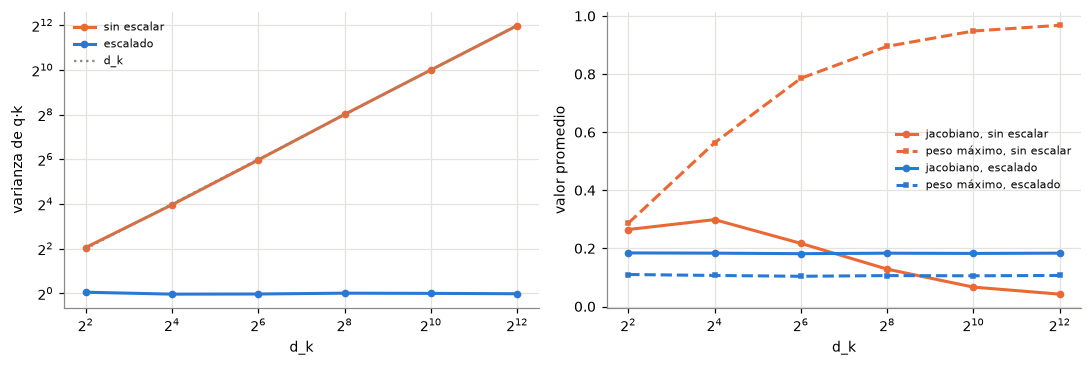

In [15]:
DIMS = [4, 16, 64, 256, 1024, 4096]
filas = []
fijar_semilla()
for d in DIMS:
    q = torch.randn(20000, d)
    k = torch.randn(20000, d)
    punto = (q * k).sum(-1)
    s = torch.randn(500, 64, d)
    logits = (torch.randn(500, 1, d) * s).sum(-1)
    for escala, nombre in [(1.0, "sin escalar"), (1 / math.sqrt(d), "escalado")]:
        p = torch.softmax(logits * escala, dim=-1)
        # jacobiano de softmax
        jac = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)
        filas.append({"d_k": d, "versión": nombre, "varianza de q·k": float((punto * escala).var()),
                      "peso máximo": float(p.max(-1).values.mean()),
                      "norma del jacobiano": float(torch.linalg.matrix_norm(jac).mean())})
tabla_escala = pd.DataFrame(filas)
display(tabla_escala.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for nombre, color in [("sin escalar", NARANJA), ("escalado", AZUL)]:
    t = tabla_escala[tabla_escala["versión"] == nombre]
    axes[0].plot(t["d_k"], t["varianza de q·k"], color=color, marker="o", ms=4, label=nombre)
    axes[1].plot(t["d_k"], t["norma del jacobiano"], color=color, marker="o", ms=4, label=f"jacobiano, {nombre}")
    axes[1].plot(t["d_k"], t["peso máximo"], color=color, ls="--", marker="s", ms=3, label=f"peso máximo, {nombre}")
axes[0].plot(DIMS, DIMS, color=GRIS, ls=":", lw=1.5, label="d_k")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)
axes[0].set_xlabel("d_k")
axes[0].set_ylabel("varianza de q·k")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("d_k")
axes[1].set_ylabel("valor promedio")
for ax in axes:
    ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig("figuras/escalamiento.png")
plt.show()

La varianza de q · k sigue a d_k: 4.1, 15.6, 62.8, 257.8, 1,024.6 y 4,052 para d_k de 4 a 4,096, y al dividir entre √d_k queda cerca de 1 en todos los casos. Sin escalar, la softmax sobre 64 llaves se satura: el peso máximo promedio sube de 0.29 a 0.97 y la norma del jacobiano cae de 0.30 a 0.04, así que los gradientes se apagan. Con escalamiento el peso máximo se mantiene cerca de 0.11 y el jacobiano cerca de 0.18 sin importar la dimensión.

### 6.4 Costo computacional

Se mide en la GPU el tiempo y la memoria pico de un forward de atención con 12 cabezas de dimensión 64 en float16, para longitudes de 256 a 32,768 tokens. La versión ingenua es la función propia, que materializa la matriz de n por n, y se compara con F.scaled_dot_product_attention, que usa un kernel tipo FlashAttention. La memoria reportada descuenta la de Q, K y V.

n    256 | ingenua      0.10 ms       3.4 MB | SDPA     0.04 ms      0.4 MB
n    512 | ingenua      0.16 ms      12.8 MB | SDPA     0.05 ms      0.8 MB
n   1024 | ingenua      0.20 ms      49.5 MB | SDPA     0.15 ms      1.5 MB
n   2048 | ingenua      1.34 ms     195.0 MB | SDPA     0.48 ms      3.0 MB
n   4096 | ingenua      5.52 ms     774.0 MB | SDPA     1.70 ms      6.0 MB


n   8192 | ingenua     21.18 ms    3084.0 MB | SDPA     6.53 ms     12.0 MB


n  16384 | ingenua     79.29 ms   12312.0 MB | SDPA    26.58 ms     24.0 MB


n  32768 | ingenua       nan ms       nan MB | SDPA   103.42 ms     48.0 MB


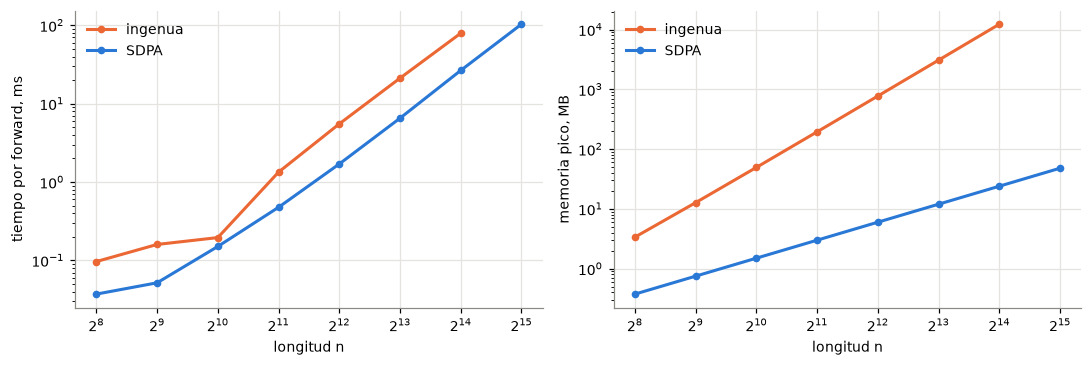

pendiente log-log de ingenua ms desde n = 2048: 1.96
pendiente log-log de ingenua MB desde n = 2048: 1.99
pendiente log-log de SDPA ms desde n = 2048: 1.95
pendiente log-log de SDPA MB desde n = 2048: 1.00


In [16]:
def medir(funcion, n, rep=10):
    Q, K, V = torch.randn(3, 1, 12, n, 64, device=DEVICE, dtype=torch.float16).unbind(0)
    torch.cuda.synchronize()
    # memoria sin entradas
    base = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    try:
        with torch.no_grad():
            funcion(Q, K, V)
            torch.cuda.synchronize()
            pico = torch.cuda.max_memory_allocated() - base
            t0 = time.perf_counter()
            for _ in range(rep):
                funcion(Q, K, V)
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) / rep * 1000, pico / 2**20
    except torch.OutOfMemoryError:
        return float("nan"), float("nan")
    finally:
        del Q, K, V
        torch.cuda.empty_cache()

LONGITUDES = [256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
medir(lambda q, k, v: atencion(q, k, v)[0], 256)
medir(F.scaled_dot_product_attention, 256)
filas = []
for n in LONGITUDES:
    t_i, m_i = medir(lambda q, k, v: atencion(q, k, v)[0], n) if n <= 16384 else (float("nan"), float("nan"))
    t_f, m_f = medir(F.scaled_dot_product_attention, n)
    filas.append({"n": n, "ingenua ms": t_i, "ingenua MB": m_i, "SDPA ms": t_f, "SDPA MB": m_f})
    print(f"n {n:6d} | ingenua {t_i:9.2f} ms {m_i:9.1f} MB | SDPA {t_f:8.2f} ms {m_f:8.1f} MB")
tabla_costo = pd.DataFrame(filas)
tabla_costo.to_csv("resultados/costo.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for col, ax, eje in [("ms", axes[0], "tiempo por forward, ms"), ("MB", axes[1], "memoria pico, MB")]:
    ax.plot(tabla_costo["n"], tabla_costo[f"ingenua {col}"], color=NARANJA, marker="o", ms=4, label="ingenua")
    ax.plot(tabla_costo["n"], tabla_costo[f"SDPA {col}"], color=AZUL, marker="o", ms=4, label="SDPA")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlabel("longitud n")
    ax.set_ylabel(eje)
    ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figuras/costo.png")
plt.show()

def pendiente(col, desde=2048):
    t = tabla_costo[(tabla_costo["n"] >= desde)].dropna(subset=[col])
    return np.polyfit(np.log(t["n"]), np.log(t[col]), 1)[0]

for col in ["ingenua ms", "ingenua MB", "SDPA ms", "SDPA MB"]:
    print(f"pendiente log-log de {col} desde n = 2048: {pendiente(col):.2f}")

La versión ingenua crece con pendiente log-log de 1.96 en tiempo y 1.99 en memoria, es decir, de forma cuadrática en ambos, y con 16,384 tokens ya usa 12.3 GB. Con 32,768 necesitaría unos 49 GB, más de lo que tiene la GPU, por lo que no se ejecuta. F.scaled_dot_product_attention sigue siendo cuadrática en tiempo, con pendiente 1.95, porque calcula exactamente la misma atención, pero es unas 3 veces más rápida y su memoria crece de forma lineal, con pendiente 1.00 y solo 48 MB con 32,768 tokens, porque procesa la matriz por bloques sin guardarla.

In [17]:
resumen = {
    "hardware": HARDWARE,
    "cabezas_bert": CAB_BERT, "cabezas_gpt2": CAB_GPT2,
    "patrones_bert": resumen_patrones(PAT_BERT).to_dict(), "patrones_gpt2": resumen_patrones(PAT_GPT2).to_dict(),
    "it_cumplen": int((margen > 0).sum()), "it_ranking": ranking.head(8).to_dict("records"),
    "sumidero": tabla_sumidero.to_dict(), "entropia": tabla_entropia.to_dict(),
    "verificaciones": VERIF, "escalamiento": tabla_escala.to_dict("records"), "costo": tabla_costo.to_dict("records"),
}
with open("resultados/resumen.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=1, default=float, ensure_ascii=False)
print("Hardware utilizado:", HARDWARE["gpu"], "|", HARDWARE["cpu"])

Hardware utilizado: NVIDIA GeForce RTX 5070 Ti | AMD Ryzen 7 7800X3D 8-Core Processor


## 7. Discusión y análisis

### Por qué la atención permitió modelos más grandes

Una RNN procesa un token a la vez, mientras que la atención calcula todas las posiciones en paralelo con multiplicaciones de matrices que aprovechan al máximo GPUs y TPUs. Además, el camino entre dos tokens cualesquiera tiene longitud 1 en lugar de n, lo que facilita aprender dependencias largas y mantiene el gradiente estable gracias a las conexiones residuales. El precio es el costo cuadrático en la longitud, aceptable para contextos de miles de tokens y aliviado por kernels como FlashAttention, como muestra la sección 6.4.

### Especialización de las cabezas

Hay evidencia clara de especialización: cabezas casi puras de token anterior, de token siguiente, de [SEP], de comas y de la misma palabra, y 22 cabezas de BERT que distinguen el referente de it. Pero no todas parecen útiles: 44 cabezas de BERT y 104 de GPT-2 dan más de la mitad de su atención a un sumidero, un comportamiento cercano a no hacer nada. Esto coincide con Michel et al., que mostraron que se puede podar la mayoría de las cabezas con poca pérdida.

### ¿Los pesos de atención explican las decisiones?

Solo en parte. Jain y Wallace mostraron que pesos de atención muy distintos pueden producir la misma predicción y que no siempre coinciden con otras medidas de importancia. Wiegreffe y Pinter respondieron que la atención puede ser una explicación plausible si se compara contra alternativas adecuadas, aunque no sea la única. En estos resultados los sumideros reciben la mayor parte del peso sin aportar contenido, y la correferencia aparece solo en algunas cabezas de capas intermedias, mientras que la representación final mezcla 144 cabezas, los vectores de valor y las redes feed-forward, que los pesos no muestran.

### Cuándo preferir una RNN o una CNN

Siguen siendo buenas opciones cuando los datos llegan en flujo y hay que procesarlos en tiempo real con memoria constante, como audio o sensores, con hardware limitado, o con pocos datos, donde el sesgo de localidad de una CNN o la recurrencia de una RNN ayudan a generalizar.

### Documentos de 100,000 tokens

Con atención estándar la matriz de puntuaciones tendría 10¹⁰ elementos, unos 20 GB en float16 por cabeza y por capa, imposible de guardar en una GPU. Se considerarían FlashAttention para evitar materializar la matriz, atención por ventanas o dispersa como Longformer, atención lineal, modelos de espacio de estados, o dividir el documento y recuperar solo los fragmentos relevantes.


## Referencias

Brenndoerfer, M. (2026, 11 de febrero). Attention visualization: Extracting and interpreting weights. https://mbrenndoerfer.com/writing/attention-visualization

Cho, A., Kim, G. C., Karpekov, A., Helbling, A., Wang, Z. J., Lee, S., Hoover, B. y Chau, D. H. (s. f.). Transformer Explainer: LLM Transformer model visually explained. Georgia Institute of Technology. Recuperado el 5 de octubre de 2026, de https://poloclub.github.io/transformer-explainer/

Guessous, D. (2024, 9 de octubre). (Beta) Implementing high-performance transformers with scaled dot product attention (SDPA). PyTorch Tutorials. https://docs.pytorch.org/tutorials/intermediate/scaled_dot_product_attention_tutorial.html

Liu, Y., Yu, J., Xu, Y., Li, Z. y Zhu, Q. (2025). A survey on transformer context extension: Approaches and evaluation (Versión 2) [Preprint]. arXiv. https://doi.org/10.48550/arXiv.2503.13299